# Crop Disease Detection — Evaluation
Analyzing model performance on the test set.

In [11]:
import json
import random
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = Path("models")
DATA_DIR  = Path("data/PlantVillage")
print("Using:", DEVICE)

Using: cuda


In [12]:
with open(MODEL_DIR / "class_names.json") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES}")

# Rebuild model architecture
model = models.efficientnet_b2(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

# Load saved weights
checkpoint = torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"Saved val accuracy: {checkpoint['val_acc']:.4f}")

Classes: 16


C:\Users\Pranj\AppData\Local\Temp\ipykernel_26712\3289104580.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_DIR / "best_model.pth", map_l

Loaded model from epoch 13
Saved val accuracy: 0.9576


In [13]:
class PlantDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        self.classes   = sorted([d.name for d in self.data_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            for img_path in (self.data_dir / cls).glob("*.jpg"):
                self.samples.append((img_path, self.class_to_idx[cls]))
            for img_path in (self.data_dir / cls).glob("*.JPG"):
                self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

from torch.utils.data import random_split

full_dataset = PlantDataset(DATA_DIR, transform=transform)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val   = int(0.1 * n_total)
n_test  = n_total - n_train - n_val

_, _, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=0)
print(f"Test samples: {len(test_set):,}")


Test samples: 4,128


In [14]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")


Test Accuracy: 0.9525  (95.25%)


In [15]:
short_names = [n.replace("___", " - ").replace("_", " ") for n in class_names]

# only use classes that actually appear in the test set
present_labels = sorted(set(all_labels))
present_names  = [short_names[i] for i in present_labels]

report = classification_report(all_labels, all_preds, labels=present_labels, target_names=present_names)
print(report)

                                             precision    recall  f1-score   support

              Pepper  bell - Bacterial spot       0.98      0.97      0.98       203
                     Pepper  bell - healthy       0.97      1.00      0.98       293
                      Potato - Early blight       0.96      0.99      0.97       176
                       Potato - Late blight       0.96      0.95      0.96       198
                           Potato - healthy       0.97      1.00      0.99        35
                      Tomato Bacterial spot       0.97      0.98      0.97       425
                        Tomato Early blight       0.92      0.79      0.85       215
                         Tomato Late blight       0.91      0.93      0.92       384
                           Tomato Leaf Mold       0.92      0.95      0.94       167
                  Tomato Septoria leaf spot       0.92      0.94      0.93       376
Tomato Spider mites Two spotted spider mite       0.92      0.96

<Axes: >

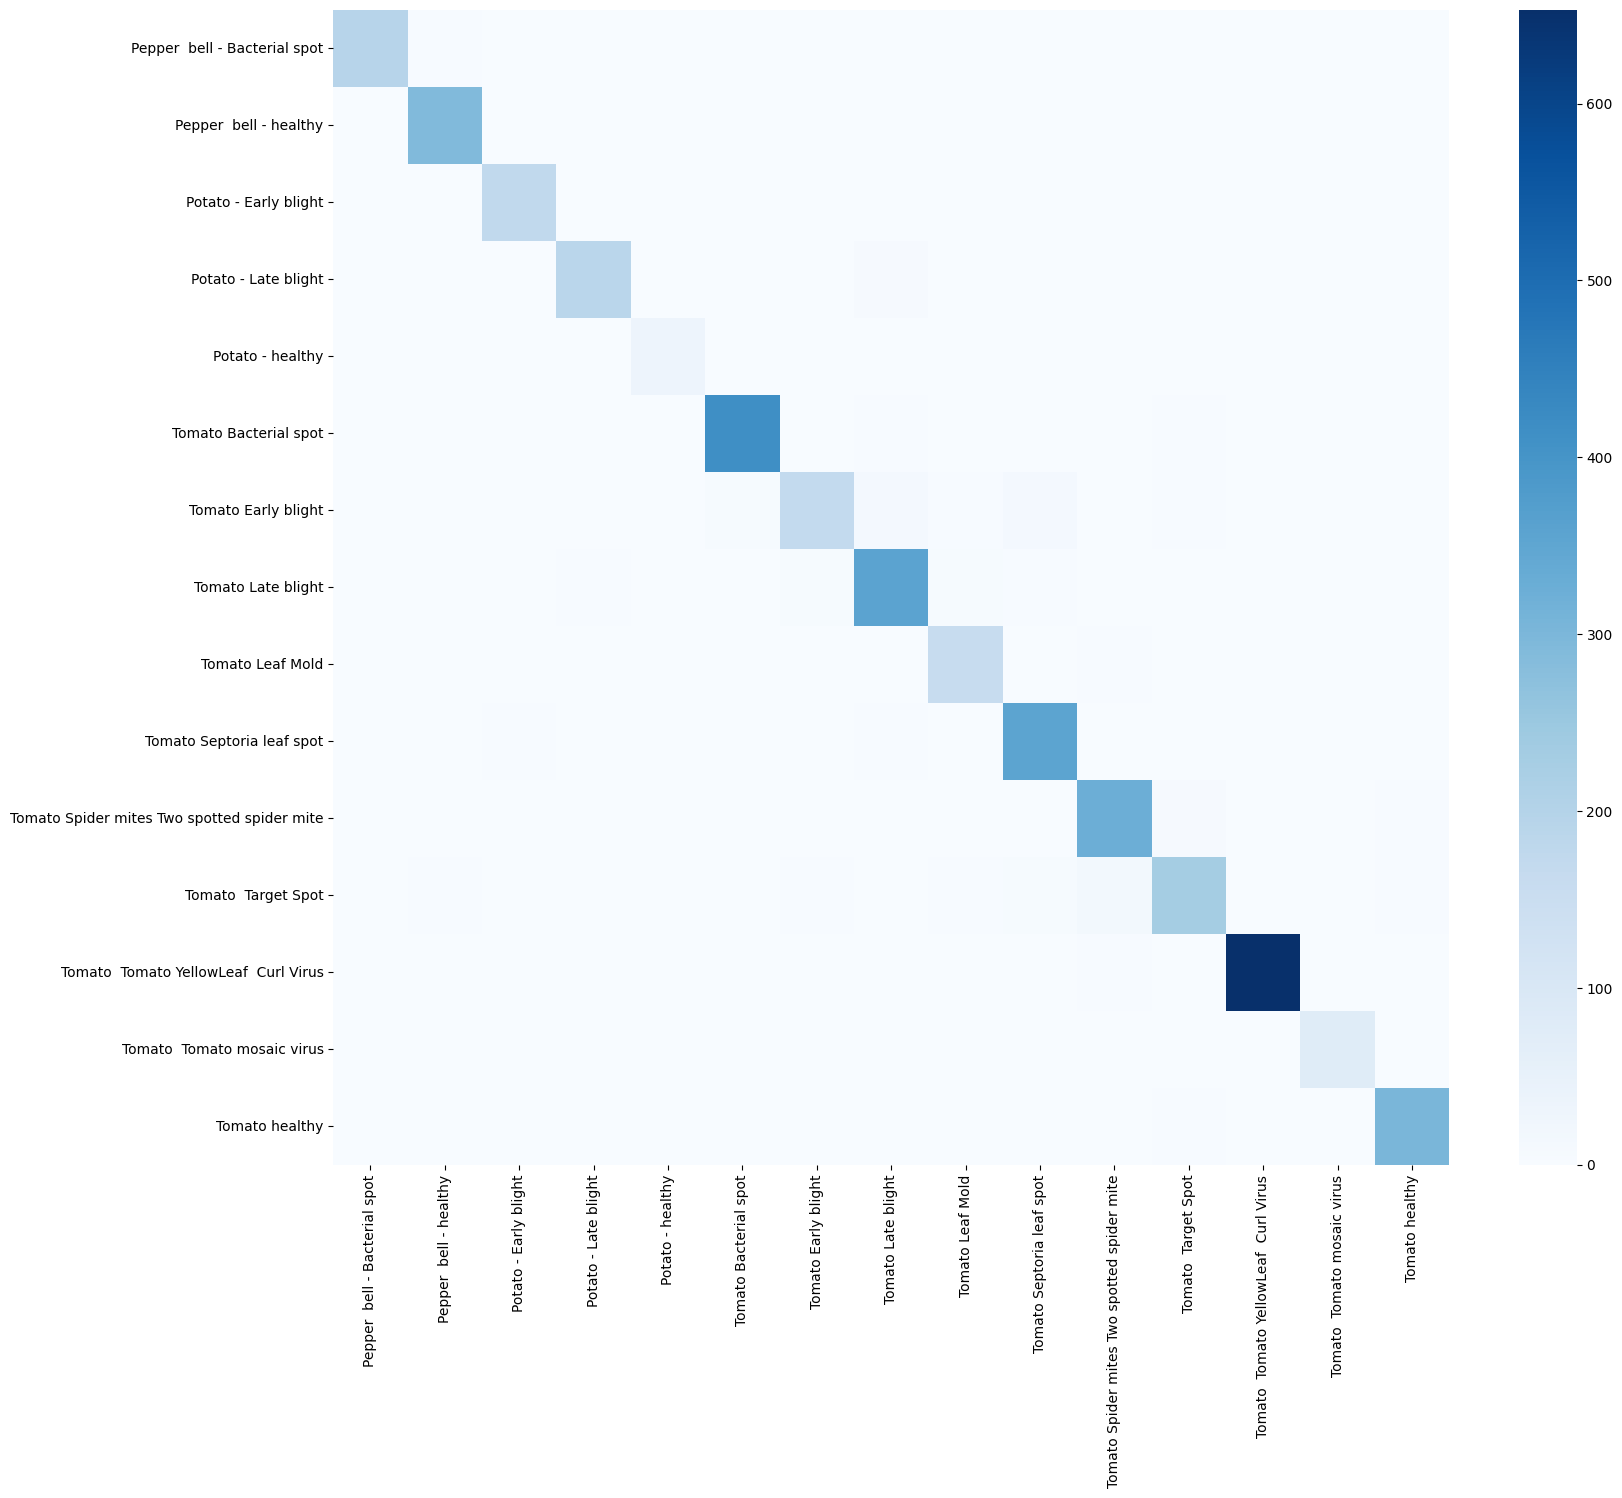

In [16]:
cm = confusion_matrix(all_labels, all_preds, labels=present_labels)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=present_names, yticklabels=present_names)

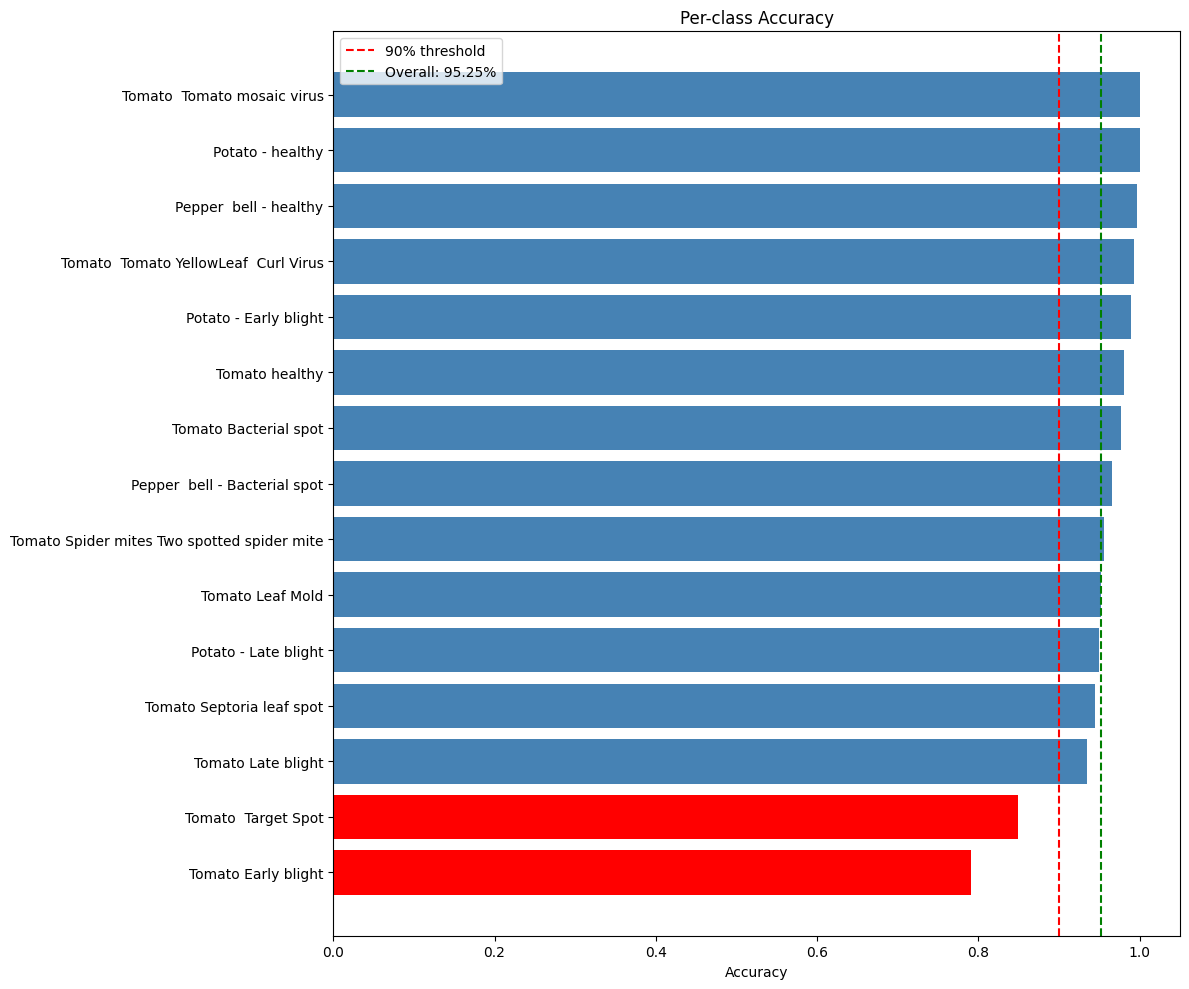

Lowest accuracy classes:
  Tomato Early blight: 0.7907
  Tomato  Target Spot: 0.8487
  Tomato Late blight: 0.9349
  Tomato Septoria leaf spot: 0.9441
  Potato - Late blight: 0.9495


In [17]:
per_class_acc = []
for i in present_labels:
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).mean()
    per_class_acc.append((short_names[i], acc))

per_class_acc.sort(key=lambda x: x[1])
names_sorted = [x[0] for x in per_class_acc]
accs_sorted  = [x[1] for x in per_class_acc]
colors = ["red" if a < 0.90 else "steelblue" for a in accs_sorted]

plt.figure(figsize=(12, 10))
plt.barh(names_sorted, accs_sorted, color=colors)
plt.axvline(0.90, color="red",   linestyle="--", label="90% threshold")
plt.axvline(test_acc, color="green", linestyle="--", label=f"Overall: {test_acc:.2%}")
plt.xlabel("Accuracy")
plt.title("Per-class Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("per_class_accuracy.png")
plt.show()

print("Lowest accuracy classes:")
for name, acc in per_class_acc[:5]:
    print(f"  {name}: {acc:.4f}")

Total misclassified: 196 / 4128


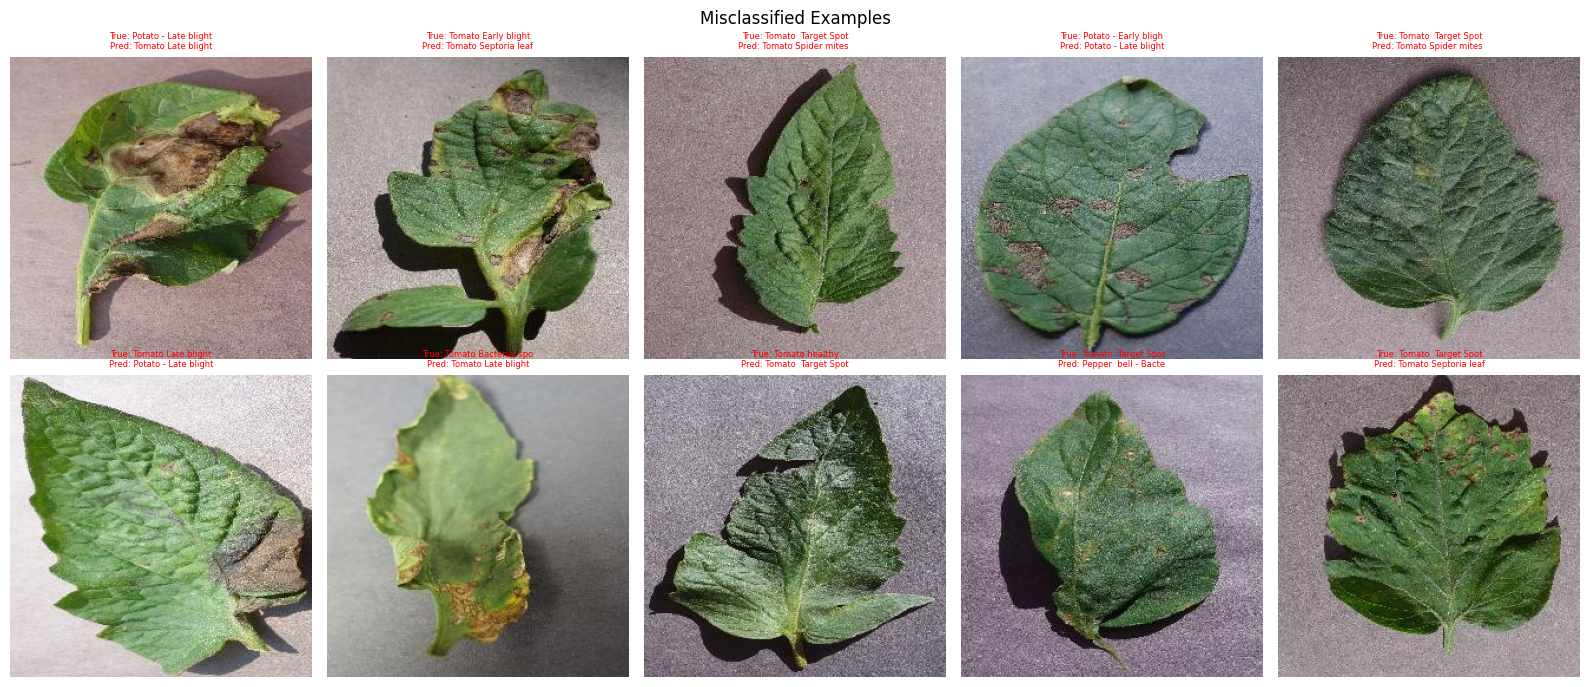

In [18]:
# Find misclassified indices
wrong_indices = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(wrong_indices)} / {len(all_labels)}")

# Show 10 random mistakes
sample_wrong = random.sample(list(wrong_indices), min(10, len(wrong_indices)))

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for ax, idx in zip(axes, sample_wrong):
    img_path, _ = test_set.dataset.samples[test_set.indices[idx]]
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    true_label = short_names[all_labels[idx]]
    pred_label = short_names[all_preds[idx]]
    ax.set_title(f"True: {true_label[:20]}\nPred: {pred_label[:20]}", fontsize=6, color="red")
    ax.axis("off")

plt.suptitle("Misclassified Examples", fontsize=12)
plt.tight_layout()
plt.savefig("misclassified.png")
plt.show()
